In [1]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device: CPU 224 cores


In [2]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random
from scipy.optimize import minimize

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

## -- Machine Learning --
import sklearn

from sklearn.base import clone
from sklearn.frozen import FrozenEstimator

from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.utils.class_weight import compute_class_weight

from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay

from sklearn.metrics import balanced_accuracy_score, log_loss, RocCurveDisplay
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, LabelEncoder, label_binarize

from sklearn.ensemble import HistGradientBoostingClassifier, ExtraTreesClassifier

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [3]:
## -- Global Settings --
# sklearn.set_config(transform_output='pandas')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [4]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e6/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
    test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

    ORIG_PATH = '/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/'
    orig = pd.read_csv(ORIG_PATH+'star_classification.csv')#.drop(['customerID'], axis=1)
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e4 | Irrigation Need/_irrigation_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv').drop('id', axis=1)
    test = pd.read_csv(PATH+'test.csv').drop('id', axis=1)
    orig = pd.read_csv(PATH+'irrigation_prediction.csv')#.drop(['customerID'], axis=1)

## =================================================================================

TARGET = train.columns[-1]
CATS   = ['spectral_type', 'galaxy_population']

NUMS = [c for c in train.columns if c not in CATS+[TARGET, 'id']]
BASE = NUMS + CATS

mapping   = {c: i for i, c in enumerate(train[TARGET].unique())}
r_mapping = {i: c for i, c in enumerate(train[TARGET].unique())}

for df in [train, orig]:
    df[TARGET] = df[TARGET].map(mapping)

for (name, df) in [('Train', train), ('Test', test), ('Original', orig)]:
    print(f"{name} shape: {df.shape}")

print(f"\nTotal nums: {len(NUMS)}")
print(f"Total cats: {len(CATS)}")
print(f"Total base: {len(BASE)}")

Train shape: (577347, 11)
Test shape: (247435, 10)
Original shape: (100000, 18)

Total nums: 8
Total cats: 2
Total base: 10


In [5]:
display(train.head())
train.info()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,0
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,0
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,1
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,0
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,0


<class 'pandas.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   alpha              577347 non-null  float64
 1   delta              577347 non-null  float64
 2   u                  577347 non-null  float64
 3   g                  577347 non-null  float64
 4   r                  577347 non-null  float64
 5   i                  577347 non-null  float64
 6   z                  577347 non-null  float64
 7   redshift           577347 non-null  float64
 8   spectral_type      577347 non-null  str    
 9   galaxy_population  577347 non-null  str    
 10  class              577347 non-null  int64  
dtypes: float64(8), int64(1), str(2)
memory usage: 55.6 MB


In [6]:
train.describe() 

,alpha,delta,u,g,r,i,z,redshift,class
count,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135,0.489465
std,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070,0.732431
min,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970,0.000000
25%,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052,0.000000
50%,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525,0.000000
75%,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390,1.000000
max,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780,2.000000


In [7]:
## -- ['spectral_type', 'galaxy_population'] derivation for original data --
def spectral_type(g, r):
    return pd.cut(
        r-g, 
        [-np.inf, -1, -0.5, 0, np.inf],
        labels=['M', 'G/K', 'A/F', 'O/B']
    ).astype(str)

def galaxy_population(u, r):
    return pd.cut(
        u-r, 
        [-np.inf, 2.2, np.inf],
        labels=['Blue_Cloud', 'Red_Sequence']
    ).astype(str)

orig['spectral_type'] = spectral_type(orig.g, orig.r)
orig['galaxy_population'] = galaxy_population(orig.u, orig.r)

orig

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,spectral_type,galaxy_population
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,0,0.634794,5812,56354,171,M,Red_Sequence
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,0,0.779136,10445,58158,427,A/F,Blue_Cloud
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,0,0.644195,4576,55592,299,M,Red_Sequence
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,0,0.932346,9149,58039,775,M,Blue_Cloud
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,0,0.116123,6121,56187,842,M,Red_Sequence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1.237679e+18,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,7778,301,2,581,1.055431e+19,0,0.000000,9374,57749,438,M,Blue_Cloud
99996,1.237679e+18,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,7917,301,1,289,8.586351e+18,0,0.404895,7626,56934,866,M,Red_Sequence
99997,1.237668e+18,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,5314,301,4,308,3.112008e+18,0,0.143366,2764,54535,74,M,Red_Sequence
99998,1.237661e+18,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,3650,301,4,131,7.601080e+18,0,0.455040,6751,56368,470,M,Red_Sequence


findfont: Failed to find font weight semibold, now using 700.


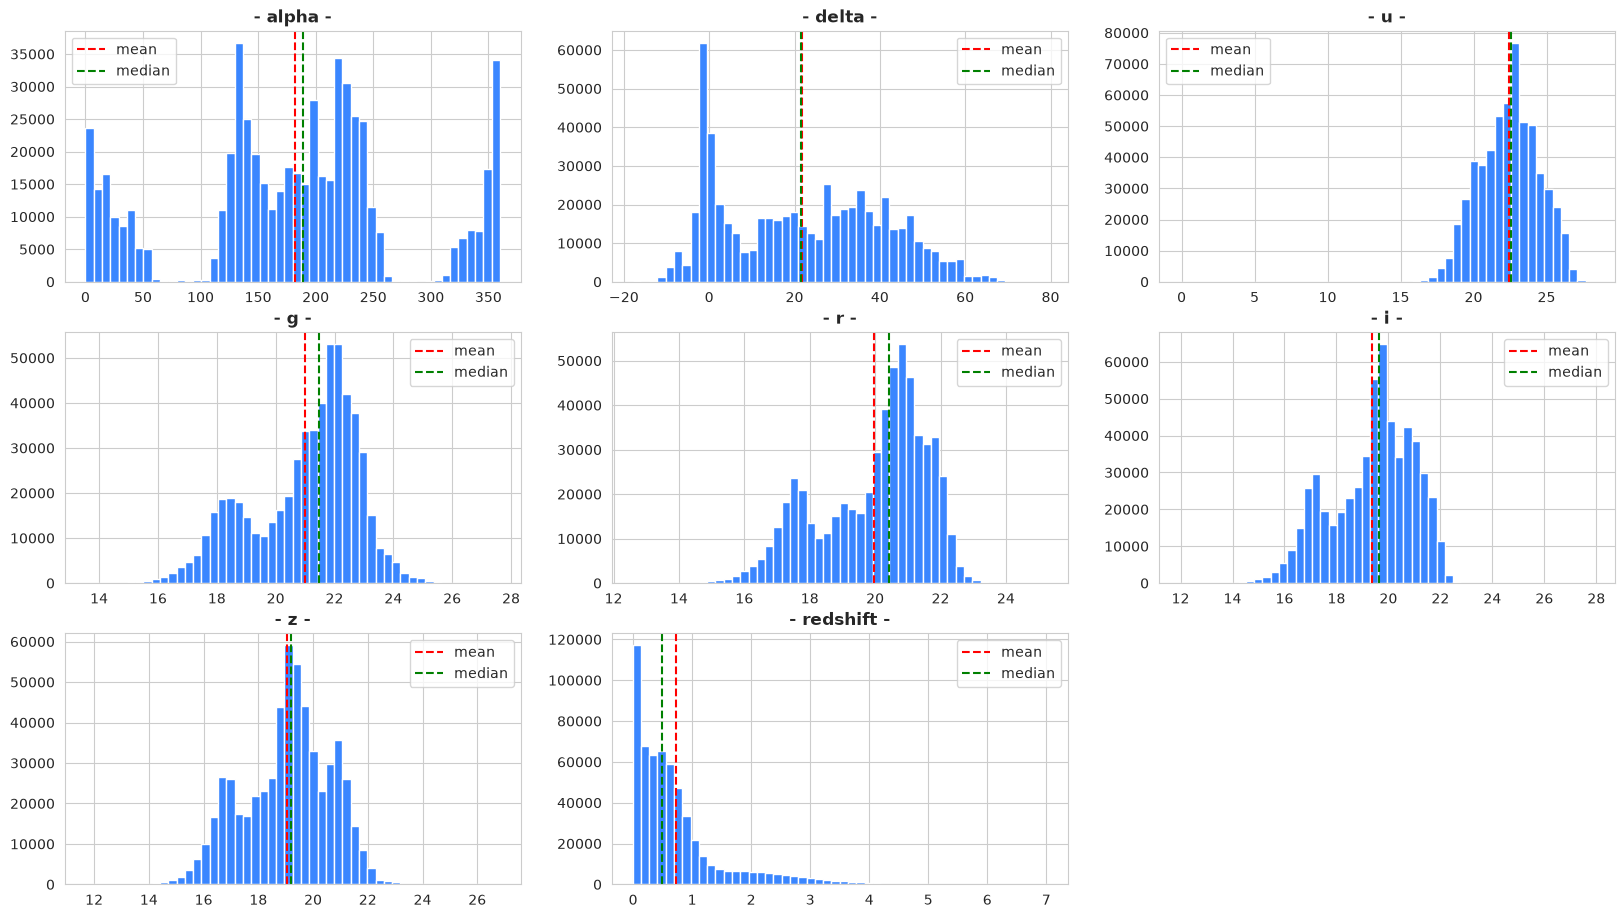

In [8]:
plt.figure(figsize=(20, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='g', linestyle='--', label='median')
    plt.title(f'- {col} -', fontweight='semibold')
    plt.legend()
    
plt.show()

In [9]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    # ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         # pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient(cmap='inferno')

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
Train,439819,444062,577347,577347,577347,577347,577347,573975,4,2
Test,200893,201819,247435,247435,247435,247435,247435,246031,4,2


## FEATURE ENGINEERING

In [10]:
def get_class_weights(y):
    """
    y: Current y_labels -> array_like or series
    """
    weights_ = compute_class_weight('balanced', classes=np.unique(y), y=y)
    return weights_

def get_sample_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        return np.array([opt[label] for label in y])
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        class_weights = dict(zip(classes_, weights_))
        return np.array([class_weights[label] for label in y])

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

def multi_class_brier(y_true, y_proba, classes):
    y_onehot = label_binarize(y_true, classes=classes)
    return float(np.mean(np.sum((y_onehot - y_proba) ** 2, axis=1)))

def t_enc_multi(X_tr, X_va, X_ts, y_tr, cols, drop=False):
    X_tr_1 = X_tr.copy()
    X_va_1 = X_va.copy()
    X_ts_1 = X_ts.copy()

    te_enc = TargetEncoder(target_type='multiclass', random_state=CFG['SEED']).set_output(transform='pandas')

    X_tr_te = te_enc.fit_transform(X_tr_1[cols], y_tr)
    X_va_te = te_enc.transform(X_va_1[cols])
    X_ts_te = te_enc.transform(X_ts_1[cols])

    te_names = [f"_TE_{c}" for c in X_tr_te.columns]
    X_tr_1[te_names] = X_tr_te
    X_va_1[te_names] = X_va_te
    X_ts_1[te_names] = X_ts_te

    if drop:
        X_tr_1 = X_tr_1.drop(columns=cols)
        X_va_1 = X_va_1.drop(columns=cols)
        X_ts_1 = X_ts_1.drop(columns=cols)

    return X_tr_1, X_va_1, X_ts_1

print('- Helper Functions Ready -')

- Helper Functions Ready -


In [11]:
from sklearn.inspection import permutation_importance

def plot_permutation_importance(model, X, y, categories):
    for c in categories:
        X[c] = X[c].factorize()[0]
        X[c] = X[c].astype('category')
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0)
    
    ## -- Train Model --
    print('Training base model... ', end='')
    model.fit(
        X_train,
        y_train,
        # sample_weight = get_sample_weights(y_train, y)
        # eval_class_weight=get_class_weights(y_train, y),
    )

    model_importances = pd.Series(model.feature_importances_, index=X.columns)
    preds = model.predict_proba(X_test)
    score = balanced_acc(y_test, preds)
    print('Complete!', end='')
    print(f" • Balanced_Accuracy: {score:.5f}")

    ## -- Compute Permutation Importances --
    print('Training permutation... ', end='')
    result = permutation_importance(
        model, X_test, y_test,
        n_repeats=5, # max_samples=0.8,
        # sample_weight=get_weights(y_test, y),
        scoring='balanced_accuracy',
        random_state=0, n_jobs=-1,
    )
    perm_sorted_idx = result.importances_mean.argsort()
    print('Complete!')

    fig, axs = plt.subplots(1, 2, figsize=(16, 0.35*len(X.columns)))
    model_importances.sort_values().plot.barh(ax=axs[0])
    axs[0].set_xlabel("Model importance")

    axs[1].boxplot(
        result.importances[perm_sorted_idx].T,
        orientation='horizontal',
        tick_labels=X.columns[perm_sorted_idx],
        whis=(0, 100),
    )
    axs[1].axvline(x=0, color="k", linestyle="--")
    axs[1].set_xlabel("Permutaion Importance")

    _s_t = 'Model vs. Permutation on validation data'
    fig.suptitle(_s_t, y=1.00, fontweight='bold')
    _ = fig.tight_layout()

    df = pd.Series(dict(zip(
        X.columns[perm_sorted_idx],
        result.importances_mean[perm_sorted_idx].ravel()
    )))

    return df.nlargest(50, keep='all').to_frame('Importance Score')

print('Permutaion function script ready!')

Permutaion function script ready!


In [12]:
%%time 

## -- ⚠️ HistGradientBoostingClassifier has no feature importance 
# x_model = HistGradientBoostingClassifier(**{
#     'class_weight': 'balanced',
#     # 'n_jobs': -1,
#     'verbose': 0,
#     'random_state': CFG['SEED'],
# })

x_model = ExtraTreesClassifier(**{
    'class_weight': 'balanced',
    'n_jobs': -1,
    'verbose': 0,
    'random_state': CFG['SEED'],
})

# top_features_df = plot_permutation_importance(
#     x_model,
#     train[BASE],
#     train[TARGET],
#     CATS,
# )

# top_features_df

CPU times: user 39 μs, sys: 5 μs, total: 44 μs
Wall time: 48.6 μs


In [13]:
# ## -- Optimal Binning --
# try:
#     import optbinning
# except:
#     %pip install -q -U optbinning
#     import optbinning

# def _opt_multiclass_binning(
#     x_tr, y_tr, x_vl, x_ts, bin_features,
#     solver='cp', metric='mean_woe', pre_bins=100, period=100):
#     """
#     metric: 'mean_woe' or 'weighted_mean_woe': floats or 'indices': integers
#     """
#     x_train = x_tr.copy()
#     x_valid = x_vl.copy()
#     x_test  = x_ts.copy()

#     opt_modules_per_col = []
#     opt_cols = []

#     for col in tqdm(bin_features, desc='Optimal_Multiclass_Binning'):
#         # print(f'{col}... ', end='')
#         opt_multi_b = optbinning.MulticlassOptimalBinning(
#             name=col,
#             prebinning_method='cart', # d='cart', 'quantile'
#             min_prebin_size=0.02, # d=0.05
#             max_n_prebins=pre_bins, # d=20
#             # min_n_bins=2, max_n_bins=100,
#             # min_bin_size=0.1, max_bin_size=0.9,
#             solver=solver,
#             time_limit=period, # d=100 (secs)
#             # verbose=True,
#         )

#         opt_multi_b.fit(x_train[col].to_numpy(), y_tr.to_numpy())
#         # display(optb.information(print_level=0))

#         new_col = f'{col}_optBin'
#         x_train.loc[:, new_col] = opt_multi_b.transform(x_train[col].to_numpy(), metric=metric)
#         x_valid.loc[:, new_col] = opt_multi_b.transform(x_valid[col].to_numpy(), metric=metric)
#         x_test.loc[:, new_col]  = opt_multi_b.transform(x_test[col].to_numpy(),  metric=metric)

#         opt_cols.append(new_col)
#         opt_modules_per_col.append(opt_multi_b)

#     # print(f'Done!')

#     return opt_modules_per_col, opt_cols, x_train, x_valid, x_test

# print('Binning function ready')

In [14]:
# opt_bins, opt_bin_cols, train2, orig2, test2 = _opt_multiclass_binning(
#     x_tr=train,
#     y_tr=train[TARGET],
#     x_vl=orig,
#     x_ts=test,
#     bin_features=NUMS,
#     solver='mip', # 'cp', 'mip', 'lr'
#     metric='weighted_mean_woe', # 'mean_woe','weighted_mean_woe','indices','bins'
#     pre_bins=100, 
#     period=100,
# )

# print(f"Total bin features: {len(opt_bin_cols)}")
# train2.head()

In [15]:
# BIN_TABLES = []

# for opt_ in opt_bins:
#     # print(opt_bins[col_n].status, opt_bins[col_n].splits)
#     opt_table = opt_.binning_table
#     opt_table.build()
#     # display(opt_table.build())
#     BIN_TABLES.append(opt_table)

# print('Binned features:', len(BIN_TABLES))
# print('Classes:', BIN_TABLES[0].classes)

# ## -- Plot optimal bin points --
# for i, opt_ in enumerate(BIN_TABLES):
#     opt_.plot(show_bin_labels=True, figsize=(18, 5))
#     print()

In [16]:
# for col in opt_bin_cols:
#     print(f"{col}: {train2[col].nunique()}")

In [17]:
# BIN_TABLES[0].analysis()

In [18]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [19]:
for col in ['alpha', 'delta', 'redshift']:
    print(f"\nRounding... ", end='')
    for r in range(-3, 6):
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')
        ## -- Drop irrelevant features --
        if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
            DROP_COLS.append(r_n)
        else:
            ROUNDS.append(r_n)

    # print(f"\nDigitizing... ", end='')
    # for d in range(-3, 7):
    #     d_n = f'{col}_digit_{d}'
    #     print(d_n+', ', end='')
    #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
    #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
    #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
    #     ## -- Drop constant features --
    #     if train[d_n].nunique() < digit_thresh:
    #         DROP_COLS.append(d_n)
    #     else:
    #         DIGITS.append(d_n)

    # print(f"\nEqual binning... ", end='')
    # for b in [32, 64, 128]: # 100, 500, 1000
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    # print(f"\nQuantile binning... ", end='')
    # for q in [32, 64, 128]:
    #     q_n = f'{col}_Qbin_{q}'
    #     print(q_n+', ', end='')
    #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
    #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ ROUNDS: {len(ROUNDS)}')
print(f"✅ DIGITS: {len(DIGITS)}")
print(f"✅ E_BINS: {len(E_BINS)}")
print(f"✅ Q_BINS: {len(Q_BINS)}")


Rounding... alpha_round_-3, alpha_round_-2, 

alpha_round_-1, alpha_round_0, alpha_round_1, alpha_round_2, alpha_round_3, alpha_round_4, alpha_round_5, 


Rounding... delta_round_-3, delta_round_-2, delta_round_-1, 

delta_round_0, delta_round_1, delta_round_2, delta_round_3, delta_round_4, delta_round_5, 
Rounding... redshift_round_-3, redshift_round_-2, redshift_round_-1, redshift_round_0, 

redshift_round_1, 

redshift_round_2, redshift_round_3, redshift_round_4, redshift_round_5, 
✅ ROUNDS: 21
✅ DIGITS: 0
✅ E_BINS: 0
✅ Q_BINS: 0


In [20]:
for col in ['delta']: # 'u', 'g', 'r', 'i', 'z',
    # print(f"\nRounding... ", end='')
    # for r in range(-3, 5):
    #     r_n = f"{col}_round_{r}"
    #     print(r_n+', ', end='')
    #     train[r_n] = train[col].round(r).astype('int32')
    #     test[r_n]  = test[col].round(r).astype('int32')
    #     orig[r_n]  = orig[col].round(r).astype('int32')
    #     ## -- Drop irrelevant features --
    #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
    #         DROP_COLS.append(r_n)
    #     else:
    #         ROUNDS.append(r_n)
    
    # print(f"\nExtracting digits... ", end='')
    # for d in range(-3, 6):
    #     d_n = f'{col}_digit_{d}'
    #     print(d_n+', ', end='')
    #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
    #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
    #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

    #     ## -- Drop constant features --
    #     if train[d_n].nunique() < digit_thresh:
    #         DROP_COLS.append(d_n)
    #     else:
    #         DIGITS.append(d_n)

    # print(f"\nEqual binning... ", end='')
    # for b in [100]: # 50, 100, 400
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     # Fit on train data and transform both train and test
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    print(f"\nQuantile binning.. ", end='')
    for q in [90, 180, 360]: 
        q_n = f'{col}_qbin_{q}'
        print(q_n+', ', end='')
        train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
        test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ ROUNDS: {len(ROUNDS)}')
print(f"✅ DIGITS: {len(DIGITS)}")
print(f"✅ E_BINS: {len(E_BINS)}")
print(f"✅ Q_BINS: {len(Q_BINS)}")


Quantile binning.. delta_qbin_90, 

delta_qbin_180, delta_qbin_360, 


✅ ROUNDS: 21
✅ DIGITS: 0
✅ E_BINS: 0
✅ Q_BINS: 3


In [21]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}\n")

train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

Features dropped: ['alpha_round_-3', 'delta_round_-3', 'delta_round_-2', 'redshift_round_-3', 'redshift_round_-2', 'redshift_round_-1']



alpha_round_-2        5
alpha_round_-1       37
alpha_round_0       343
alpha_round_1       340
alpha_round_2       340
alpha_round_3       339
alpha_round_4       338
alpha_round_5       338
delta_round_-1       11
delta_round_0        95
delta_round_1        93
delta_round_2        92
delta_round_3        92
delta_round_4        92
delta_round_5        92
redshift_round_0      8
redshift_round_1      8
redshift_round_2      8
redshift_round_3      8
redshift_round_4      8
redshift_round_5      8
delta_qbin_90        90
delta_qbin_180      180
delta_qbin_360      360
dtype: int64

In [22]:
# def add_frequency_condition(df1, cols, thresh=5):
#     df = df1.copy()
#     for c in cols:
#         # 1. Get value counts
#         v_counts = df[c].value_counts()
#         # 2. Identify values to replace (count <= threshold)
#         to_replace = v_counts[v_counts <= thresh].index
#         # 3. Apply condition: if value in low-freq list, assign 0, else keep it
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# for df in [train, test, orig]:
#     df = add_frequency_condition(df, DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [23]:
# ## -- Arithmetic interaction --

# for df in tqdm([train, test, orig]):
#     df['u_g_sub_'] = df['u'] - df['g']
#     df['g_r_sub_'] = df['g'] - df['r']

#     df['g_i_sub_'] = df['g'] - df['i']
#     df['r_z_sub_'] = df['r'] - df['z']

#     df['i_z_sub_'] = df['i'] - df['z']
#     df['r_i_sub_'] = df['r'] - df['i']
#     df['u_z_sub_'] = df['u'] - df['z']
    
#     df['stellar_locus_dist'] = np.sqrt((df['g_r_sub_'] - 0.52)**2 + (df['r_i_sub_'] - 0.25)**2)

#     for band in ['g', 'i']:
#         b_col = f"_div_{band}_redshift"
#         df[b_col] = df[band] / (df['redshift'] + 1e-6)

# color_bands = [c for c in train.columns if c.endswith('_sub_') or c.endswith('_div_')]
# color_bands.append('stellar_locus_dist')

# train[color_bands].describe()

In [24]:
## -- Arithmetic interaction --
BANDS = ['u', 'g', 'r', 'i', 'z']
COLOR_PAIRS = [
    ('u', 'g'),
    ('g', 'r'),
    ('i', 'z'),
    ('r', 'z'),
    ('u', 'z'),
    ('r', 'i'),
]

for df in tqdm([train, test, orig]):
    for a, b in COLOR_PAIRS:
        df[f"_{a}_{b}"] = (df[a] - df[b]).astype('float32')

    for band in ['g', 'i']:
        df[f"_div_{band}_redshift"] = (df[band] / (df['redshift']+1e-6)).astype('float32')

    df['_log_redshift'] = np.log1p(df['redshift']).astype('float32')
    df['_sky_dist'] = np.sqrt(df['alpha']**2 + df['delta']**2)
    df['_stellar_locus_dist'] = np.sqrt((df['_g_r'] - 0.52)**2 + (df['_r_i'] - 0.25)**2)

    # df["_mean_bands"] = df[BANDS].mean(axis=1)
    # df["_std_bands"] = df[BANDS].std(axis=1)
    # df["_skew_bands"] = df[BANDS].skew(axis=1)
    # df["_max_bands"] = df[BANDS].max(axis=1)
    # df["_min_bands"] = df[BANDS].min(axis=1)
    # df["_range_bands"] = df["_max_bands"] - df["_min_bands"]

  0%|          | 0/3 [00:00<?, ?it/s]

In [25]:
## -- Cyclic encoding --
for df in tqdm([train, test, orig]):
    for col in ['alpha', 'delta']:
        for p in [180, 360]:
            df[f"{col}_sin_{p}"] = np.sin(2 * np.pi * df[col] / p).astype('float32')
            df[f"{col}_cos_{p}"] = np.cos(2 * np.pi * df[col] / p).astype('float32')

  0%|          | 0/3 [00:00<?, ?it/s]

In [26]:
# ## -- Frequency encoding --
# freq_cols = []

# print(f"\nCreate frequencies... ", end='')
# for col in ['spectral_type']:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_freq'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     freq_cols.append(n)

# print()
# print(f"✅ Total frequency features: {len(freq_cols)}")

# train[freq_cols].head()

In [27]:
INTER = []

for c1, c2 in tqdm(list(itertools.combinations(CATS, 2)), desc='Pairwise'):
    n_col = f"_Bi_{c1}-|-{c2}"
    train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
    test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
    orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
    INTER.append(n_col)

# for c1, c2, c3 in tqdm(list(itertools.combinations(TOP_COLS, 3)), desc='Triplewise'):
#     n_col = f"_Tri_{c1}-|-{c2}-|-{c3}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
#     INTER.append(n_col)

# for c1, c2 in tqdm(list(itertools.product(TOP_COLS, LOW_COLS)), desc='One-to-Many'):
#     n_col = f"_Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

print(f"Total interaction features: {len(INTER)}")

train[INTER].head()

Pairwise:   0%|          | 0/1 [00:00<?, ?it/s]

Total interaction features: 1


,_Bi_spectral_type-|-galaxy_population
0,M_Red_Sequence
1,M_Red_Sequence
2,O/B_Blue_Cloud
3,M_Red_Sequence
4,M_Red_Sequence


In [28]:
# ## -- Reduce data memory --
# def reduce_memory(df):
#     old_size = sys.getsizeof(df) / (1024*1024)
#     for c in tqdm(df.columns, desc='Reducing memory...'):
#         ## -- Downcast Integer type ---
#         if df[c].dtype == np.int64: 
#             if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
#                 df[c] = df[c].astype(np.int32)
#                 # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
#                 #     df[c] = df[c].astype(np.int16)
#                 #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
#                 #         df[c] = df[c].astype(np.int8)
#         ## -- Downcast Float type -----
#         # elif df[c].dtype == np.float64:
#         #     if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
#         #         df[c] = df[c].astype(np.float32)
#                 # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
#                 #     df[c] = df[c].astype(np.float16)

#     new_size = sys.getsizeof(df) / (1024*1024)
#     print(f"Size before process: {old_size:.1f}MB")
#     print(f"Size after process : {new_size:.1f}MB\n")
    
#     return df

# train = reduce_memory(train)
# test = reduce_memory(test)
# orig = reduce_memory(orig)

# gc.collect()

# print(f"Data memory reduced!")

In [29]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== CategoryMeanEncoder =====

class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [30]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [31]:
# train, test, _, orig_cols = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE,
#     target=TARGET,
#     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
#     # fill_nan=True,
# )

# print(f"Appended original features: {len(orig_cols)}")

In [32]:
# ## -- Duplicate all numerics as categories --
# CATS_2 = []

# for c in NUMS:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     orig[n]  = orig[c].copy()
#     CATS_2.append(n)

#     ## -- FACTORIZE CATS_2 --
#     combine  = pd.concat([train[n], test[n], orig[n]])
#     v = combine.factorize()[0]
#     train[n] = v[:len(train)].astype('int32')
#     test[n]  = v[len(train):len(train)+len(test)].astype('int32')
#     orig[n]  = v[len(train)+len(test):].astype('int32')

# print(f'Numericals to Categoricals: {len(CATS_2)}')

In [33]:
# %%time

# ## -- Check permutation feature importances --
# x_model = ExtraTreesClassifier(**{
#     # 'max_iter': 5000,
#     # 'learning_rate': 0.05,
#     # 'max_features': 0.1,
#     # 'n_iter_no_change': 100,
#     # 'l2_regularization': 5.0,
#     # 'scoring': 'loss', # 'loss', 'roc_auc'
#     'class_weight': 'balanced',
#     'verbose': 0,
#     'n_jobs': -1,
#     'random_state': CFG['SEED'],
# })

# top_features_df = plot_permutation_importance(
#     x_model,
#     train.drop(columns=[TARGET]),
#     train[TARGET],
#     CATS+INTER,
# )

# top_features_df

In [34]:
## -- Factorize using combined data --
for c in CATS+INTER:
    combine  = pd.concat([train[c], test[c], orig[c]])
    combine  = combine.factorize()[0]
    combine  = pd.Series(combine).astype('category')
    train[c] = combine[:len(train)]
    test[c]  = combine[len(train):len(train)+len(test)]
    orig[c]  = combine[len(train)+len(test):]

print('Label encoding complete!')

Label encoding complete!


In [35]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head(3)

Total Features: 54


,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class,alpha_round_-2,alpha_round_-1,alpha_round_0,alpha_round_1,alpha_round_2,alpha_round_3,alpha_round_4,alpha_round_5,delta_round_-1,delta_round_0,delta_round_1,delta_round_2,delta_round_3,delta_round_4,delta_round_5,redshift_round_0,redshift_round_1,redshift_round_2,redshift_round_3,redshift_round_4,redshift_round_5,delta_qbin_90,delta_qbin_180,delta_qbin_360,_u_g,_g_r,_i_z,_r_z,_u_z,_r_i,_div_g_redshift,_div_i_redshift,_log_redshift,_sky_dist,_stellar_locus_dist,alpha_sin_180,alpha_cos_180,alpha_sin_360,alpha_cos_360,delta_sin_180,delta_cos_180,delta_sin_360,delta_cos_360,_Bi_spectral_type-|-galaxy_population
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,0,0,0,100,150,148,147,147,147,147,147,20,17,17,16,16,16,16,0,0,0,0,0,0,38,77,155,3.576564,1.537632,0.636056,1.736869,6.851065,1.100813,53.536564,47.085331,0.342868,148.704497,1.326446,-0.902822,0.430015,0.533847,-0.845581,0.558014,0.829832,0.291692,0.956512,0
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,0,0,0,100,130,128,128,127,127,127,127,30,32,32,32,32,32,32,0,0,0,0,0,0,59,119,238,1.691447,1.499854,0.439634,0.800775,3.992076,0.361141,120.821922,109.041748,0.146673,132.012922,0.986137,-0.970200,-0.242305,0.788132,-0.615506,0.904034,0.427461,0.535041,0.844826,0
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,1,1,1,200,180,180,179,179,179,179,179,40,35,35,35,35,35,35,3,2,2,2,2,2,64,129,258,-0.043925,-0.092712,0.025263,0.614474,0.477837,0.589211,7.464886,7.289058,1.341237,183.233878,0.700343,-0.007238,0.999974,0.003619,-0.999993,0.943741,0.330684,0.578496,0.815685,1


# ML TRAINING

In [36]:
try:
    from venn_abers import VennAbersCalibrator
    # from cir_model import CenteredIsotonicRegression
except:
    %pip install -q -U venn-abers
    from venn_abers import VennAbersCalibrator
    # from cir_model import CenteredIsotonicRegression

print()

!pip show venn_abers


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



Name: venn-abers
Version: 1.5.3
Summary: Venn-ABERS calibration package
Home-page: https://github.com/ip200/venn-abers
Author: Ivan Petej
Author-email: ivan@algorhythmic.ai
License: MIT
Location: /usr/local/lib/python3.12/site-packages
Requires: numpy, pandas, scikit-learn
Required-by: 


In [37]:
# ## -- Test TE outputs --
# te = TargetEncoder(target_type='multiclass', random_state=CFG['SEED']).set_output(transform='pandas')

# orig_te = te.fit_transform(orig[CATS], orig[TARGET])
# orig_te.columns = [f"TE_{c}" for c in orig_te.columns]

# pd.concat([orig[BASE+[TARGET]], orig_te], axis=1).head()

In [38]:
def Trainer_CV(model_name, params, train_df, test_df, features, target, kf, calibrate=False):
    print(f"\n===== Starting CV: {model_name} =====")
    start = time()

    X = train_df[features]
    y = train_df[target]

    num_cls = y.nunique()
    
    oof_preds = np.zeros((len(X), num_cls))
    test_preds = np.zeros((len(test_df), num_cls))

    fold_scores = []
    brier_scores = []
    feat_importances = []

    for idx, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        print(f"\n***** FOLD {idx+1}/{kf.n_splits} | ", end='')

        # Split data for the current fold
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test_df[features].copy()

        ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[features]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[target]], ignore_index=True)
        # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        ## -- Target Encoding --
        te_cols = ROUNDS
        print(f" • Target Encoding {len(te_cols)} features... ")
        X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, te_cols, drop=True)

        # ## -- TE Opt1. -> Using custom script --
        # te_enc = TargetEncoder(INTER, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        # X_train = te_enc.fit_transform(X_train, y_train)
        # X_valid = te_enc.transform(X_valid)
        # X_test  = te_enc.transform(X_test)

        # cm_enc  = CategoryMeanTransformer(cat_cols=ROUNDS)
        # X_train = cm_enc.fit_transform(X_train, y_train)
        # X_valid = cm_enc.transform(X_valid)
        # X_test  = cm_enc.transform(X_test)

        # combined = pd.concat([X_train, X_valid, X_test])
        # for c in cats:
        #     combined[c] = combined[c].astype(str) #.astype('category')

        # X_train = combined.iloc[:len(X_train)]
        # X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
        # X_test  = combined.iloc[len(X_train)+len(X_valid):]

        print(f"Train shape: {X_train.shape} -")

        if calibrate:
            ## -- Internal Split for Calibration --
            X_base, X_calib, y_base, y_calib = train_test_split(
                X_train, y_train, train_size=0.7, stratify=y_train, random_state=CFG['SEED']
            )

            ## -- Build base model --
            if 'hist' in model_name:
                model = HistGradientBoostingClassifier(**params)
            else:
                model = ExtraTreesClassifier(**params)

            print(f" • Training {model_name} | {X_base.shape}... ")
            model.fit(X_train, y_train)

            if 'xtra' in model_name:
                feat_importances.append(model.feature_importances_.ravel())

            base_acc   = balanced_acc(y_valid, model.predict_proba(X_valid))
            base_brier = multi_class_brier(y_valid, model.predict_proba(X_valid), np.unique(y_valid))

            ## -- Calibrate outputs --
            print(f" • Calibrating (venn-abers) {X_calib.shape}... ")
            vao = VennAbersCalibrator() # - Get OOF predictions -
            venn_oof_preds = vao.predict_proba(
                p_cal   = model.predict_proba(X_calib),
                y_cal   = y_calib.to_numpy(),
                p_test  = model.predict_proba(X_valid),
                va_type = 'one_vs_all',
            )
            oof_preds[val_idx] = venn_oof_preds

            vat = VennAbersCalibrator() # - Get TEST predictions -
            venn_test_preds = vat.predict_proba(
                p_cal   = model.predict_proba(X_calib),
                y_cal   = y_calib.to_numpy(),
                p_test  = model.predict_proba(X_test),
                va_type = 'one_vs_all',
            )
            test_preds += venn_test_preds

            ## -- Fold scores --
            fold_score  = balanced_acc(y_valid, oof_preds[val_idx])
            brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))
    
            fold_scores.append(fold_score)
            brier_scores.append(brier_score)
            print(f"{CFG['YELLOW']} • Fold {idx+1}")
            print(f"base_acc:  {base_acc:.5f} | base_brier:  {base_brier:.5f}")
            print(f"calib_acc: {fold_score:.5f} | calib_brier: {brier_score:.5f}")
            print(f"{CFG['RESET']}")
        else:
            ## -- Build calibration model --
            if 'hist' in model_name:
                model = HistGradientBoostingClassifier(**params)
            else:
                model = ExtraTreesClassifier(**params)
                
            print(f" • Training {model_name} | {X_train.shape}... ")
            model.fit(X_train, y_train)

            if 'xtra' in model_name:
                feat_importances.append(model.feature_importances_.ravel())

            ## -- Predict on val and test sets --
            oof_preds[val_idx] = model.predict_proba(X_valid)
            test_preds += model.predict_proba(X_test)
    
            ## -- Calculate and print fold score --
            fold_score = balanced_acc(y_valid, oof_preds[val_idx])
            brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))
    
            fold_scores.append(fold_score)
            brier_scores.append(brier_score)
            print(f"{CFG['YELLOW']} • Fold {idx+1} acc: {fold_score:.5f} | brier: {brier_score:.5f}{CFG['RESET']}")

        # ## -- Clean up memory --
        # del y_train, y_valid, X_test
        # gc.collect() 

    ## -- Average the test predictions --
    test_preds /= kf.n_splits

    ## -- CV results --
    print("\n==================================================")
    print(f"{kf.n_splits}-FOLD CV: {model_name}")
    print("==================================================")
    for i, (a, b) in enumerate(zip(fold_scores, brier_scores)):
        print(f" • Fold {i+1} score: {a:.5f} | brier: {b:.5f}")

    ## -- Final out-of-fold score --
    oof_score = np.round(balanced_acc(y, oof_preds), 5)
    oof_brier = np.round(multi_class_brier(y, oof_preds, np.unique(y)), 5)

    print("-------------------------------------------------|")
    print(f"OOF score: {oof_score}")
    print(f"AVG score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print("-------------------------------------------------|")
    print(f"OOF brier: {oof_brier}")
    print(f"AVG brier: {np.mean(brier_scores):.5f} ± {np.std(brier_scores):.5f}")
    print("-------------------------------------------------|")
    print(f'{((time() - start) / 60):.2f} mins')

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'scores': oof_score,
        'model': model,
        'importances': feat_importances if 'xtra' in model_name else None,
        'val_data': [X_valid, y_valid],
    }

print("⚙️ Training function ready ⚙️")

⚙️ Training function ready ⚙️


In [39]:
all_predictions = {}

USE_CALIBATOR  = False
USE_FULL_TRAIN = True

CFG['FOLDS'] = 8
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.copy()

print(f"Calibarate: {USE_CALIBATOR}\nData size: {train_data.shape}")
train_data

Calibarate: False
Data size: (577347, 55)


,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class,alpha_round_-2,alpha_round_-1,alpha_round_0,alpha_round_1,alpha_round_2,alpha_round_3,alpha_round_4,alpha_round_5,delta_round_-1,delta_round_0,delta_round_1,delta_round_2,delta_round_3,delta_round_4,delta_round_5,redshift_round_0,redshift_round_1,redshift_round_2,redshift_round_3,redshift_round_4,redshift_round_5,delta_qbin_90,delta_qbin_180,delta_qbin_360,_u_g,_g_r,_i_z,_r_z,_u_z,_r_i,_div_g_redshift,_div_i_redshift,_log_redshift,_sky_dist,_stellar_locus_dist,alpha_sin_180,alpha_cos_180,alpha_sin_360,alpha_cos_360,delta_sin_180,delta_cos_180,delta_sin_360,delta_cos_360,_Bi_spectral_type-|-galaxy_population
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,0,0,0,100,150,148,147,147,147,147,147,20,17,17,16,16,16,16,0,0,0,0,0,0,38,77,155,3.576564,1.537632,0.636056,1.736869,6.851065,1.100813,53.536564,47.085331,0.342868,148.704497,1.326446,-0.902822,0.430015,0.533847,-0.845581,0.558014,0.829832,0.291692,0.956512,0
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,0,0,0,100,130,128,128,127,127,127,127,30,32,32,32,32,32,32,0,0,0,0,0,0,59,119,238,1.691447,1.499854,0.439634,0.800775,3.992076,0.361141,120.821922,109.041748,0.146673,132.012922,0.986137,-0.970200,-0.242305,0.788132,-0.615506,0.904034,0.427461,0.535041,0.844826,0
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,1,1,1,200,180,180,179,179,179,179,179,40,35,35,35,35,35,35,3,2,2,2,2,2,64,129,258,-0.043925,-0.092712,0.025263,0.614474,0.477837,0.589211,7.464886,7.289058,1.341237,183.233878,0.700343,-0.007238,0.999974,0.003619,-0.999993,0.943741,0.330684,0.578496,0.815685,1
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,0,0,0,200,230,226,225,225,225,225,225,50,49,48,48,48,48,48,1,0,0,0,0,0,82,164,329,2.254320,2.032982,0.450706,1.102802,5.390103,0.652096,39.266460,34.257919,0.429246,230.982447,1.565502,0.999592,-0.028560,-0.717133,-0.696936,0.992248,-0.124274,0.749758,0.661712,0
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,0,0,0,100,140,142,141,141,141,141,141,20,19,19,19,19,19,19,1,0,0,0,0,0,42,84,168,2.231478,1.237231,0.283262,0.618264,4.086973,0.335002,35.035980,32.207016,0.441965,143.148996,0.722251,-0.971664,0.236368,0.617913,-0.786247,0.625048,0.780586,0.331220,0.943554,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577342,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524,0,0,0,200,220,224,223,223,223,223,223,0,3,2,2,2,2,2,1,0,0,0,0,0,22,45,90,1.974528,1.151093,0.639180,1.151752,4.277373,0.512572,36.858784,33.606422,0.413119,223.553309,0.683537,0.998700,0.050966,-0.688852,-0.724902,0.087284,0.996184,0.043684,0.999045,0
577343,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,0,0,0,200,220,224,223,223,223,223,223,40,41,40,40,40,40,40,1,0,0,0,0,0,72,144,288,1.375570,1.661308,0.232989,1.750591,4.787468,1.517602,33.950043,29.123203,0.505967,227.577557,1.705696,0.999258,0.038528,-0.693351,-0.720600,0.989115,0.147142,0.653015,0.757345,0
577344,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342,0,0,0,100,50,52,52,52,52,52,52,0,1,0,0,0,0,0,0,0,0,0,0,0,17,35,71,0.728394,2.189890,0.568879,0.822570,3.740853,0.253691,56.373665,49.880714,0.319430,52.263246,1.669894,0.968070,-0.250682,0.790785,0.612094,0.023451,0.999725,0.011726,0.999931,0
577345,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359,2,1,1,200,250,247,247,247,247,247,247,50,51,50,50,50,50,50,3,2,2,2,2,2,84,168,336,0.347115,0.635191,-0.547210,-0.490559,0.491747,0.056651,7.538373,7.297174,1.352830,252.496532,0.225062,0.710499,-0.703699,-0.922957,-0.384904,0.980547,-0.196282,0.773396,0.633923,2


In [40]:
# ## ======================== HISTOGRAM
# VERS = 'histogram_calib' if USE_CALIBATOR else 'histogram'

# if all_predictions:
#     all_predictions.clear()

# PARAMS = {
#     'max_iter': 5000,
#     'learning_rate': 0.05,
#     'max_features': 0.3,
#     'n_iter_no_change': 100,
#     # 'l2_regularization': 5.0,
#     'class_weight': 'balanced',
#     'scoring': 'balanced_accuracy',
#     'tol': 1e-4,
#     'verbose': 0,
#     'random_state': CFG['SEED'],
# }

# n = f"{VERS}"

# # for algo in [.2, .3]: #  .1, 0.5, 1.0
# #     PARAMS['max_features'] = algo
# #     n = f"{VERS}_" + str(algo).lower()
# all_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=PARAMS,
#     train_df=train_data,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=skf,
#     calibrate=USE_CALIBATOR,
# )

In [41]:
# ================================================== 
# 5-FOLD CV: histogram
# ==================================================
#  • Fold 1 score: 0.96002 | brier: 0.06701
#  • Fold 2 score: 0.95847 | brier: 0.06930
#  • Fold 3 score: 0.96071 | brier: 0.07030
#  • Fold 4 score: 0.95815 | brier: 0.07074
#  • Fold 5 score: 0.96266 | brier: 0.06355
# -------------------------------------------------|
# OOF score: 0.96
# AVG score: 0.96000 ± 0.00163
# -------------------------------------------------|
# OOF brier: 0.06818
# AVG brier: 0.06818 ± 0.00265
# -------------------------------------------------|
# 1.09 mins

In [42]:
## ================== EXTRA_TREES
VERS = 'xtraTrees_calib' if USE_CALIBATOR else 'xtraTrees'

PARAMS = {
    'n_estimators': 500,
    # # 'criterion':, 'gini', # 'gini', 'entropy', 'log_loss'
    'max_features': 0.4,
    'min_samples_leaf': 3,
    'verbose': 0,
    'n_jobs': -1,
    'random_state': CFG['SEED'],
}

n = f"{VERS}"

all_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=skf,
    calibrate=USE_CALIBATOR,
)


===== Starting CV: xtraTrees =====

***** FOLD 1/8 | 

 • Target Encoding 21 features... 


Train shape: (505178, 96) -
 • Training xtraTrees | (505178, 96)... 


 • Fold 1 acc: 0.94825 | brier: 0.05599

***** FOLD 2/8 |  • Target Encoding 21 features... 


Train shape: (505178, 96) -
 • Training xtraTrees | (505178, 96)... 


...

 • Fold 6 acc: 0.95118 | brier: 0.05517

***** FOLD 7/8 |  • Target Encoding 21 features... 


Train shape: (505179, 96) -
 • Training xtraTrees | (505179, 96)... 


 • Fold 7 acc: 0.94945 | brier: 0.05499

***** FOLD 8/8 |  • Target Encoding 21 features... 


Train shape: (505179, 96) -
 • Training xtraTrees | (505179, 96)... 


 • Fold 8 acc: 0.94934 | brier: 0.05693

8-FOLD CV: xtraTrees
 • Fold 1 score: 0.94825 | brier: 0.05599
 • Fold 2 score: 0.95146 | brier: 0.05465
 • Fold 3 score: 0.95229 | brier: 0.05527
 • Fold 4 score: 0.94858 | brier: 0.05696
 • Fold 5 score: 0.94979 | brier: 0.05631
 • Fold 6 score: 0.95118 | brier: 0.05517
 • Fold 7 score: 0.94945 | brier: 0.05499
 • Fold 8 score: 0.94934 | brier: 0.05693
-------------------------------------------------|
OOF score: 0.95004
AVG score: 0.95004 ± 0.00135
-------------------------------------------------|
OOF brier: 0.05578
AVG brier: 0.05578 ± 0.00084
-------------------------------------------------|
14.03 mins


In [43]:
# ==================================================
# 5-FOLD CV: xtraTrees
# ==================================================
#  • Fold 1 score: 0.94601 | brier: 0.06031
#  • Fold 2 score: 0.94357 | brier: 0.06123
#  • Fold 3 score: 0.94317 | brier: 0.06126
#  • Fold 4 score: 0.95014 | brier: 0.05928
#  • Fold 5 score: 0.94702 | brier: 0.05957
# -------------------------------------------------|
# OOF score: 0.94598
# AVG score: 0.94598 ± 0.00253
# -------------------------------------------------|
# OOF brier: 0.06033
# AVG brier: 0.06033 ± 0.00082
# -------------------------------------------------|
# 1.05 mins

findfont: Failed to find font weight semibold, now using 700.


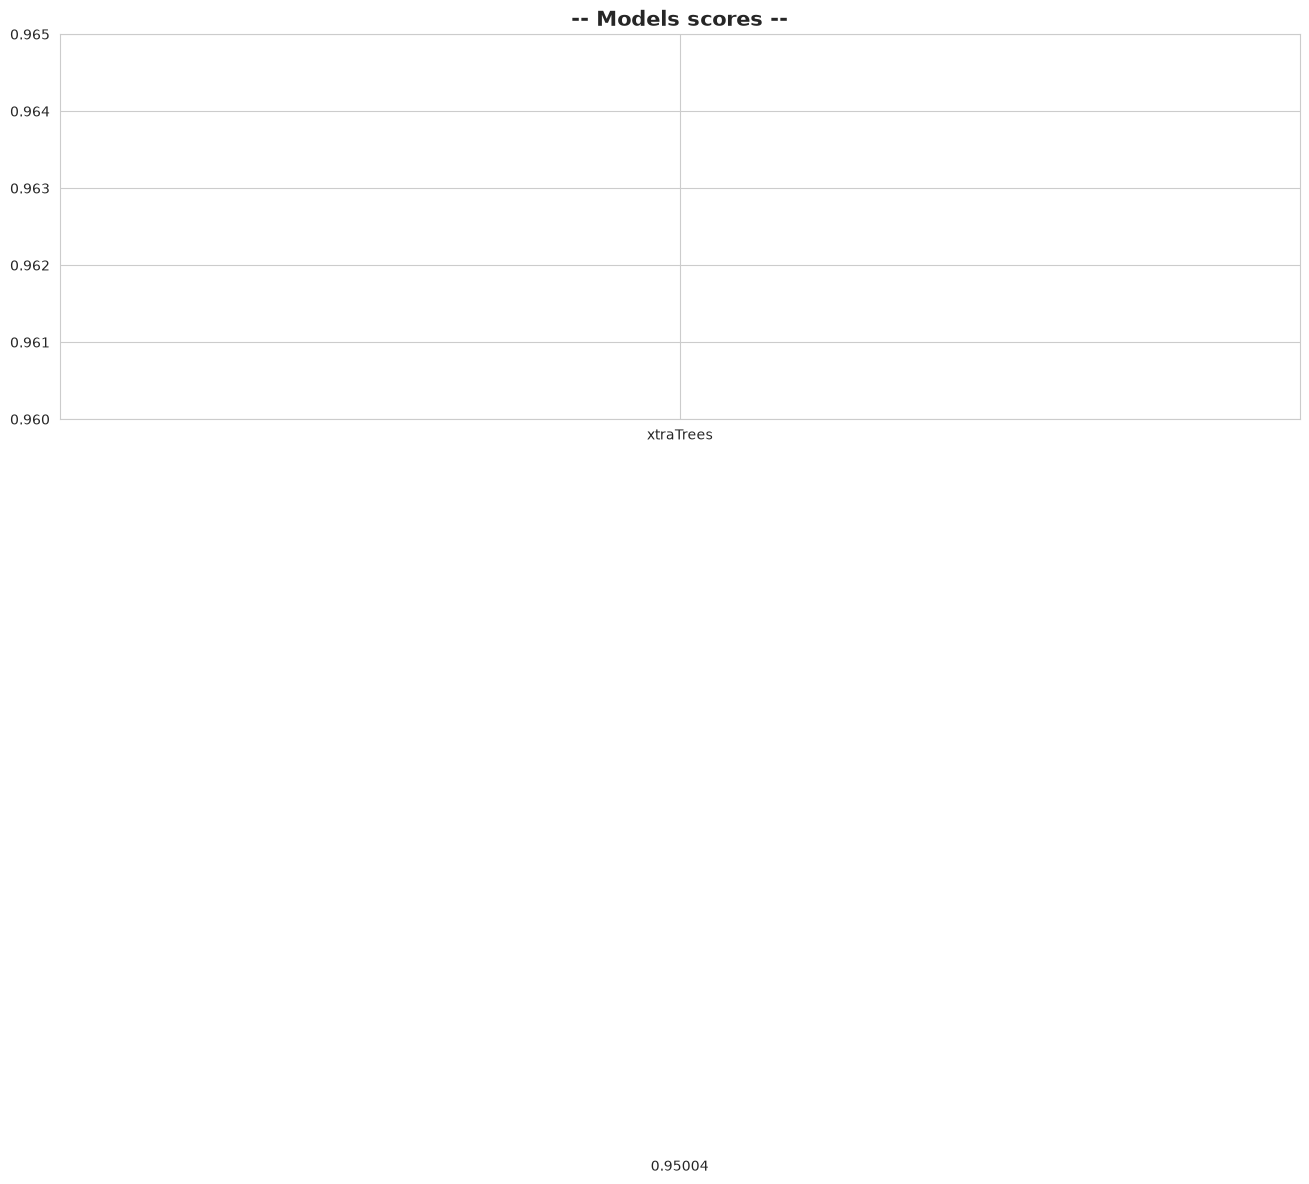

In [44]:
## -- Get model scores --

all_model_scores = {}
all_scores = []

for k, v in all_predictions.items():
    for x, y in v.items():
        if x == 'scores':
            all_model_scores[k] = y
            all_scores.append(float(y))

plt.figure(figsize=(16, 5))
ax = sns.lineplot(all_model_scores, marker='o')

ax.fill_between(range(len(all_model_scores)), all_model_scores.values(), alpha=0.3)
ax.set_title("-- Models scores --", fontsize=15, fontweight='semibold')
ax.tick_params('x', rotation=0)
ax.set_ylim(0.96, 0.965)

for i, s in enumerate(all_model_scores.values()):
    ax.text(float(i), s+2e-4, s, ha='center', va='baseline')

plt.tight_layout()
plt.show()

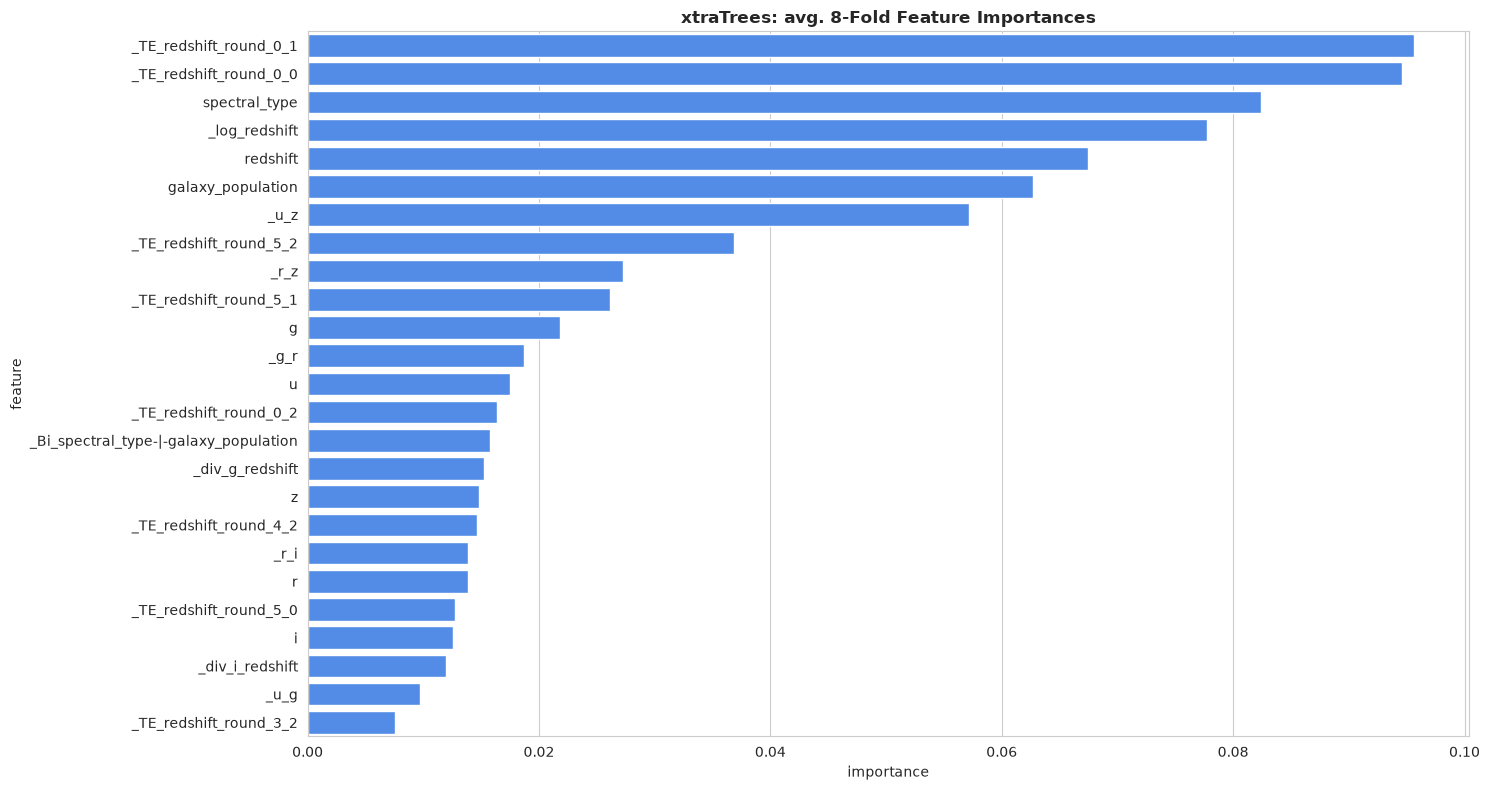

In [45]:
## -- Get feature importances --
all_feat_importances = {}
all_val_data = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == 'importances':
            if y is not None:
                # print(y)
                # all_feat_importances[k] = y
                all_feat_importances[k] = np.mean(y, axis=0)
        elif x == 'val_data':
            all_val_data[k] = y # -> [0] select X_val, [1] select y_valid

top_n = 25

for i, (m, fi) in enumerate(all_feat_importances.items()):
    fi_df = pd.DataFrame({
        'feature': all_val_data[m][0].columns,
        'importance': fi,
    }).sort_values(by='importance', ascending=False).reset_index(drop=True)
    
    plt.figure(figsize=(15, 8*len(all_feat_importances)))
    plt.subplot(len(all_feat_importances), 1, i+1)
    sns.barplot(data=fi_df.head(top_n), x='importance', y='feature')
    plt.title(f"{m}: avg. {CFG['FOLDS']}-Fold Feature Importances", fontweight='semibold')

    plt.tight_layout() 
    plt.show()

    print()

In [46]:
# !rm -r /kaggle/working

xtraTrees_95004 saved!


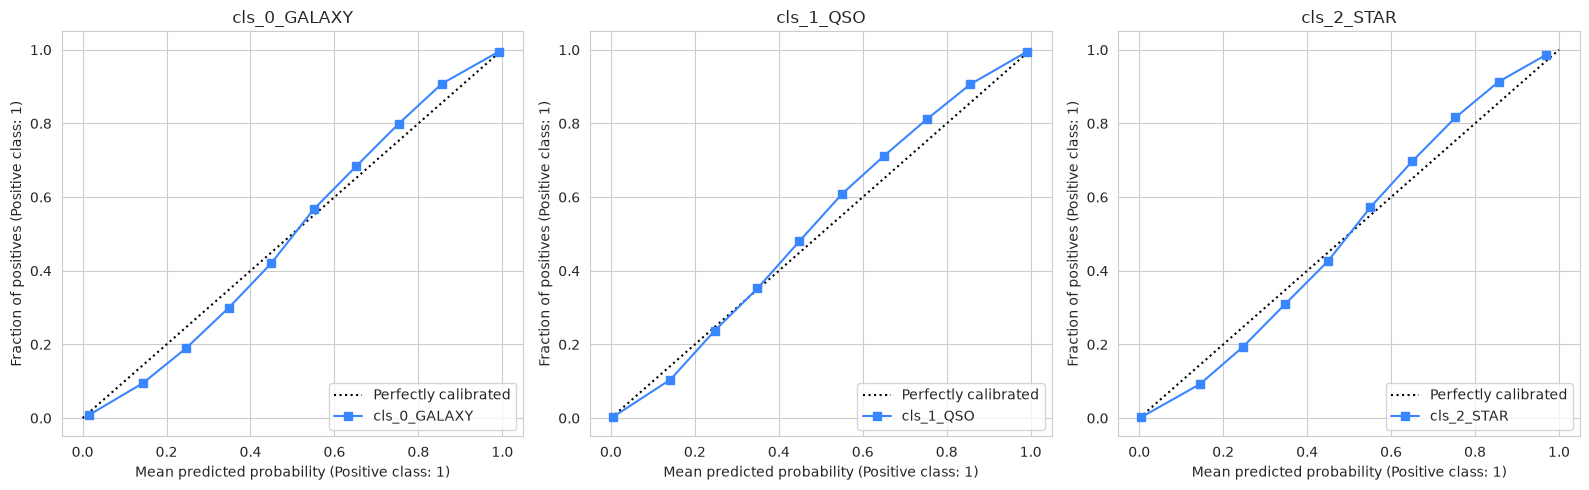

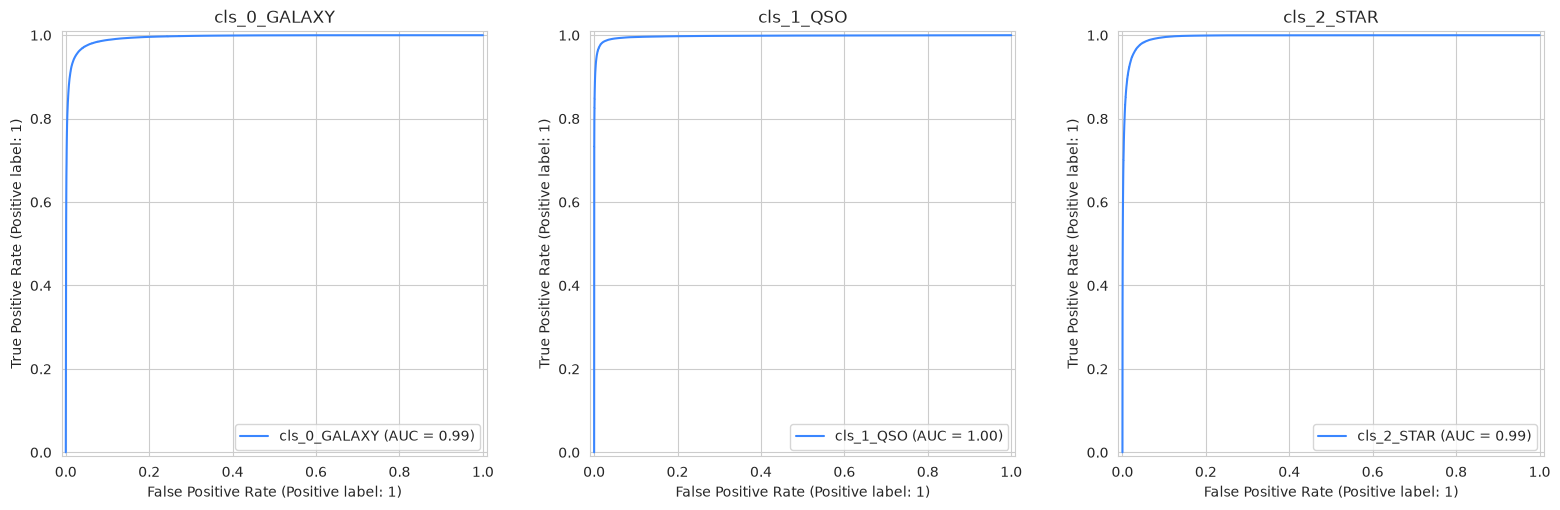

In [47]:
## -- Save OOF predictions --
# oof_predictions = []
 
for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            n = f"{k}_{str(all_scores[i]).split('.')[1]}"
            np.save(f"oof_{n}_.npy", y)
            print(f"{n} saved!")

            ## -- Plot oof distributions --
            y_labels = pd.Series(np.argmax(y, axis=1))
            cls_labels = [*mapping.keys()]
            name0 = f"cls_0_{cls_labels[0]}"
            name1 = f"cls_1_{cls_labels[1]}"
            name2 = f"cls_2_{cls_labels[2]}"
            
            y_cls_0 = (train_data[TARGET] == 0).astype(int)
            y_cls_1 = (train_data[TARGET] == 1).astype(int)
            y_cls_2 = (train_data[TARGET] == 2).astype(int)
            p_cls_0 = y[:, 0]
            p_cls_1 = y[:, 1]
            p_cls_2 = y[:, 2]
            
            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            CalibrationDisplay.from_predictions(y_cls_0, p_cls_0, n_bins=10, name=name0, ax=axs[0])
            CalibrationDisplay.from_predictions(y_cls_1, p_cls_1, n_bins=10, name=name1, ax=axs[1])
            CalibrationDisplay.from_predictions(y_cls_2, p_cls_2, n_bins=10, name=name2, ax=axs[2])
            axs[0].set_title(name0)
            axs[1].set_title(name1)
            axs[2].set_title(name2)

            # plt.suptitle(n)
            plt.tight_layout()
            plt.show()

            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            RocCurveDisplay.from_predictions(
                y_cls_0, p_cls_0, name=name0, ax=axs[0],
                # sample_weight=get_sample_weights(y_cls_0, y_cls_0),
            )
            RocCurveDisplay.from_predictions(
                y_cls_1, p_cls_1, name=name1, ax=axs[1],
                # sample_weight=get_sample_weights(y_cls_1, y_cls_1),
            )
            RocCurveDisplay.from_predictions(
                y_cls_2, p_cls_2, name=name2, ax=axs[2],
                # sample_weight=get_sample_weights(y_cls_2, y_cls_2),
            )
            axs[0].set_title(name0)
            axs[1].set_title(name1)
            axs[2].set_title(name2)
            
            # plt.suptitle(n)
            plt.tight_layout()
            plt.show()

            print()

xtraTrees_95004 saved! (247435, 3)


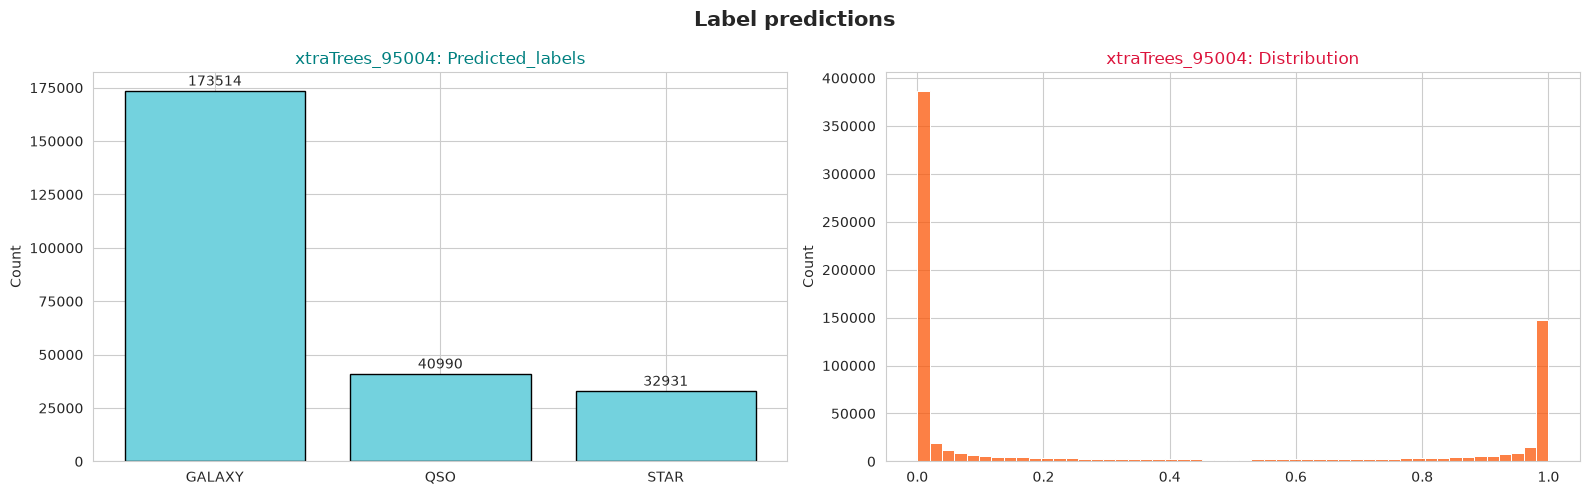

In [48]:
## -- Save TEST predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == 'test_preds':
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[i]).split('.')[1]}"
            np.save(f"test_{n}_.npy", y)

            y_labels = np.argmax(y, axis=1)

            model_results[n] = pd.Series(y_labels).map(r_mapping)

            submit[TARGET] = pd.Series(y_labels).map(r_mapping)
            submit.to_csv(f'submit_base_{n}.csv', index=False)
            print(f'{n} saved! {y.shape}')

            fig, axs = plt.subplots(1, 2, figsize=(16, 5))

            counts = [np.sum(y_labels == _) for _ in range(len(np.unique(y_labels)))]
            axs[0].bar([*mapping.keys()], counts, color='#73D2DE', edgecolor='k')
            axs[0].set_title(f"{n}: Predicted_labels", color='teal')
            axs[0].set_ylabel('Count')

            for i, c in enumerate(counts):
                axs[0].text(i, c+2500, str(c), ha='center', fontsize=10)

            sns.histplot(y.ravel(), ax=axs[1], color='#FB5607')
            axs[1].set_title(f"{n}: Distribution", color='crimson')
            
            plt.suptitle('Label predictions', fontsize=15, fontweight='semibold')
            
            plt.tight_layout()
            plt.show()

            print()

In [49]:
final_results = pd.DataFrame(model_results)
final_results

,xtraTrees_95004
0,GALAXY
1,GALAXY
2,GALAXY
3,STAR
4,GALAXY
...,...
247430,QSO
247431,QSO
247432,GALAXY
247433,QSO
